# Forest Generation Visualizations
This notebook demonstrates the terrain and forest generation pipeline, including height, moisture, and steepness maps plus a view of trees grown on the terrain.

## Setup
Import the terrain and forest builders, configure reproducibility, and set plotting defaults.

In [ ]:
import random
from copy import copy
import numpy as np
import matplotlib.pyplot as plt

from forest_gen.terrain import TerrainBuilder, TerrainConfig
from forest_gen.forest import ForestBuilder, ForestConfig
from forest_gen.asset_dist import Species

random.seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = False


## Generate terrain
Use fractal noise with microrelief and the default moisture model to build terrain arrays.

In [ ]:

terrain_config = TerrainConfig(
    size=150, resolution=0.5, scale=7.0, octaves=4, height_scale=5, apply_microrelief=True
)
terrain_gen = (
    TerrainBuilder()
    .with_noise('fractal')
    .with_microrelief(True)
    .with_moisture_model()
    .build()
)

# Push the base terrain toward chunkier hills and soft terraces
terrain_gen.noise.persistence = 0.62
terrain_gen.noise.lacunarity = 2.35
terrain_gen.micro.strength = 0.002
terrain_gen.micro.sigma = 1.1

terrain = terrain_gen.generate(terrain_config)
extent = [0, terrain_config.size, 0, terrain_config.size]

terrain.heightmap.shape, terrain.moisture.shape, terrain.slope.shape


((751, 751), (751, 751), (751, 751))

## Height map
The base height field produced by the noise generator and microrelief.

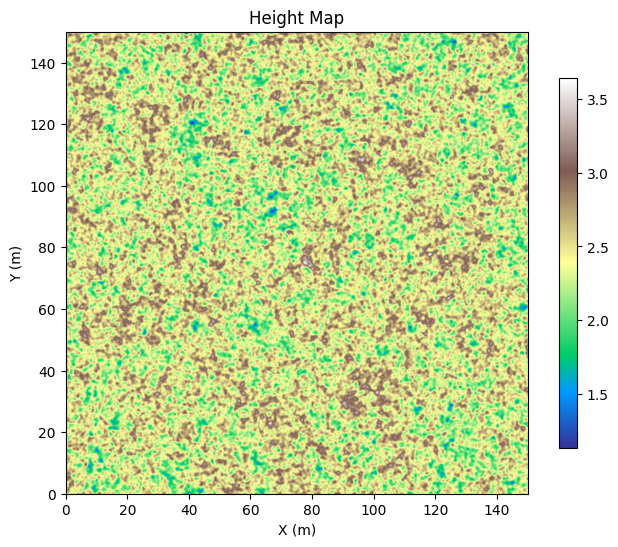

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(terrain.heightmap, cmap='terrain', origin='lower', extent=extent)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Height Map')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
plt.show()


## Moisture map
Moisture combines flow accumulation, slope penalty, and aspect factor from the default model.

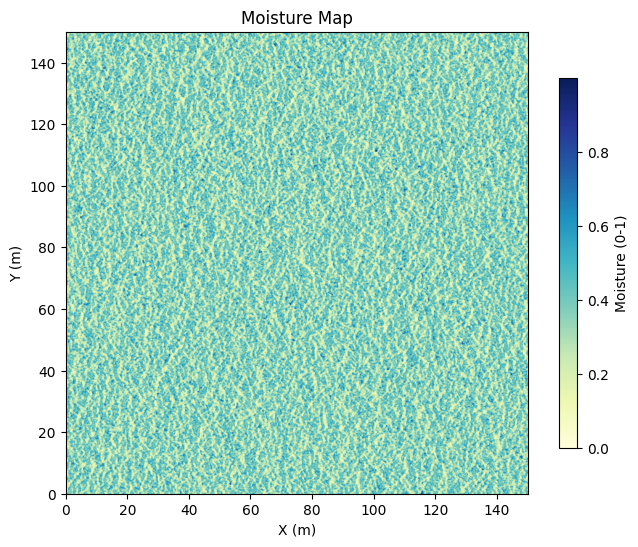

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(terrain.moisture, cmap='YlGnBu', origin='lower', extent=extent)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Moisture (0-1)')
ax.set_title('Moisture Map')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
plt.show()


## Steepness map
Slope (steepness) in degrees calculated from local height differences.

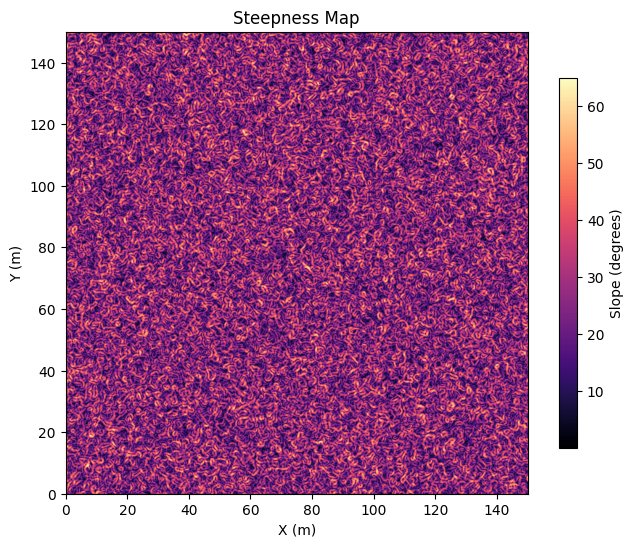

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(terrain.slope, cmap='magma', origin='lower', extent=extent)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Slope (degrees)')
ax.set_title('Steepness Map')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
plt.show()


## Forest generation and tree map
Simulate two tree species whose viability is modulated by the terrain moisture.

In [ ]:
# Species tuned for a mixed temperate stand with slower oak recruitment and wider pine dispersal
oak = Species(
    name='Oak',
    max_age=120,
    species_density=0.012,
    reproduction_rate=2,
    reproduction_radius=10.0,
    radius=1.9,
    juvenile_mortality_depth=0.45,
    juvenile_mortality_peak=0.07,
    juvenile_mortality_width=0.05,
    juvenile_recovery_age=0.18,
)
pine = Species(
    name='Pine',
    max_age=110,
    species_density=0.018,
    reproduction_rate=6,
    reproduction_radius=22.0,
    radius=1.3,
    juvenile_mortality_depth=0.3,
    juvenile_mortality_peak=0.05,
    juvenile_mortality_width=0.035,
    juvenile_recovery_age=0.15,
)

years = 8
forest_gen = (
    ForestBuilder()
    .with_size((terrain_config.size, terrain_config.size))
    .add_species('tree', oak)
    .add_species('tree', pine)
    .with_terrain(terrain)
    .build()
)
forest_state = forest_gen.generate(ForestConfig(scene_density=0.9, years=0))

forest_states = []
for _ in range(years):
    forest_state.run_state(1)
    forest_states.append([copy(plant) for plant in forest_state])

len(forest_state)


2909

## Yearly forest snapshots
Visualize the simulated tree distribution after each simulated year.

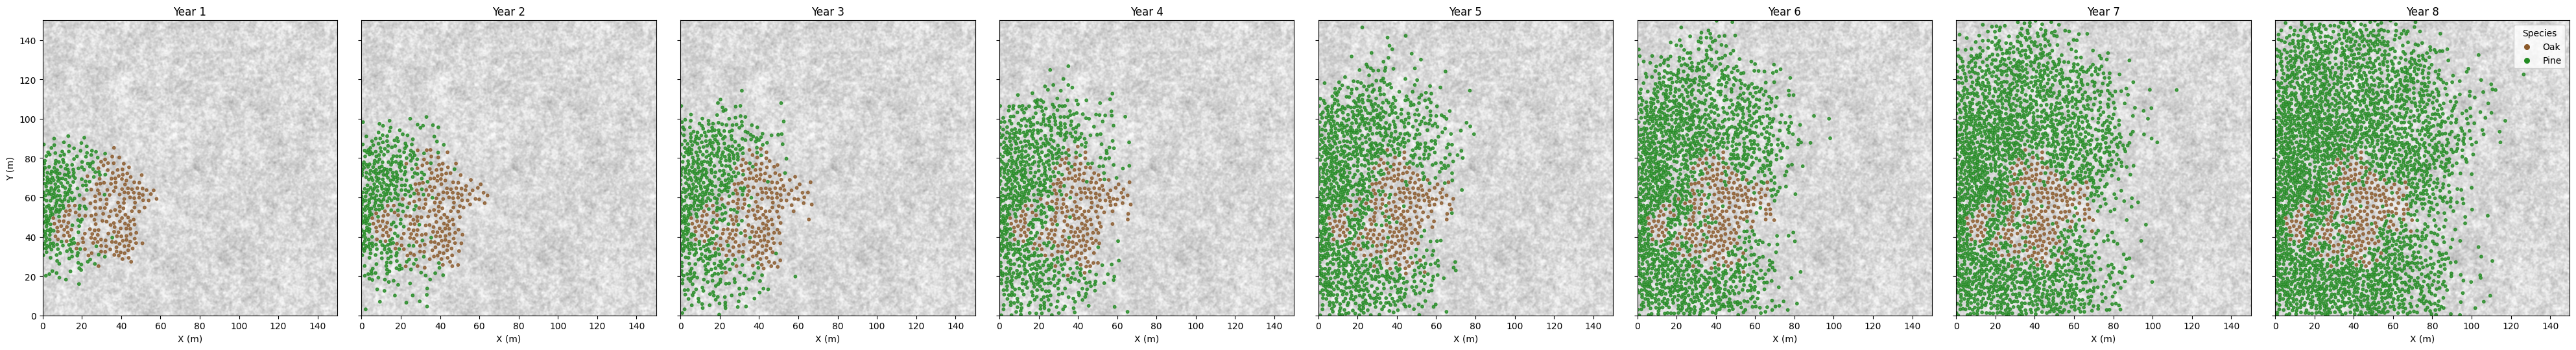

In [ ]:
fig, axes = plt.subplots(1, len(forest_states), figsize=(5 * len(forest_states), 5), sharex=True, sharey=True)
if len(forest_states) == 1:
    axes = [axes]

species_colors = {'Oak': '#8B5A2B', 'Pine': '#228B22'}
for year, (ax, plants) in enumerate(zip(axes, forest_states), start=1):
    ax.imshow(terrain.heightmap, cmap='Greys', origin='lower', extent=extent, alpha=0.35)
    xs = [plant.coords[0] for plant in plants]
    ys = [plant.coords[1] for plant in plants]
    colors = [species_colors.get(plant.species.name, 'black') for plant in plants]
    ax.scatter(xs, ys, c=colors, s=10, alpha=0.8)
    ax.set_title(f'Year {year}')
    ax.set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')

for name, color in species_colors.items():
    axes[-1].scatter([], [], c=color, label=name, s=30)
axes[-1].legend(title='Species', loc='upper right')
plt.tight_layout()
plt.show()


## Viability maps
Visualize how terrain-modified viability varies for each species before rendering the forest map.

In [ ]:
species = {'Oak': oak, 'Pine': pine}
xs = np.arange(0, terrain_config.size, terrain_config.resolution)
ys = np.arange(0, terrain_config.size, terrain_config.resolution)

viability = {}
for name, sp in species.items():
    vals = np.zeros((len(ys), len(xs)))
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            vals[i, j] = sp.viability_map(x, y)
    viability[name] = vals

fig, axes = plt.subplots(1, len(species), figsize=(14, 5), sharex=True, sharey=True)
if len(species) == 1:
    axes = [axes]
for ax, (name, vals) in zip(axes, viability.items()):
    im = ax.imshow(vals, origin='lower', cmap='viridis', extent=extent)
    ax.set_title(f'{name} Viability')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
fig.colorbar(im, ax=axes, label='Viability (0-1)', shrink=0.8)
plt.show()


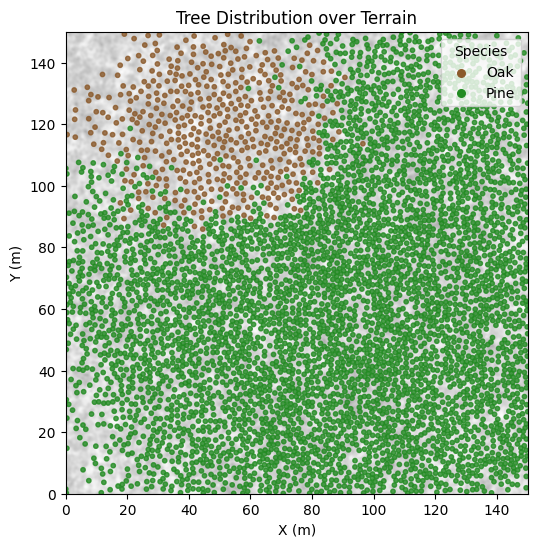

In [ ]:
fig, ax = plt.subplots()
ax.imshow(terrain.heightmap, cmap='Greys', origin='lower', extent=extent, alpha=0.35)
species_colors = {'Oak': '#8B5A2B', 'Pine': '#228B22'}
xs, ys, colors = [], [], []
for plant in forest_state:
    xs.append(plant.coords[0])
    ys.append(plant.coords[1])
    colors.append(species_colors.get(plant.species.name, 'black'))
scatter = ax.scatter(xs, ys, c=colors, s=10, alpha=0.8, label='Trees')
handles = []
labels = []
for name, color in species_colors.items():
    handles.append(ax.scatter([], [], c=color, label=name, s=30))
    labels.append(name)
ax.legend(handles, labels, title='Species', loc='upper right')
ax.set_title('Tree Distribution over Terrain')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
plt.show()
